In [33]:
from os.path import splitext, basename
import numpy as np
import healpy as hp
import pylab as pl
import pandas as pd

In [34]:
# load samples:
saveroot = "/pscratch/sd/q/qhang/cnnpz/cardinal/"
df = pd.read_parquet(saveroot + "train_100k.parquet",)

df2 = pd.read_parquet(saveroot + "test_100k.parquet",)

In [3]:
df['mag_i_lsst'].max()

25.49999695617432

## first apply error model with a few scenarios:
Will use PSF error model for simplicity
- Y4 desi: 
    - deep region
    - rest
- Y4 baseline

In [4]:
from rail.creation.degraders.photometric_errors import LSSTErrorModel
from rail.core.stage import RailStage

In [5]:
renameDict={
    "u": "mag_u_lsst",
    "g": "mag_g_lsst",
    "r": "mag_r_lsst",
    "i": "mag_i_lsst",
    "z": "mag_z_lsst",
    "y": "mag_y_lsst",
}

In [6]:
depth_y4desi_deep={
    "u": 25.11,
    "g": 26.29, 
    "r": 26.12,
    "i": 25.70,
    "z": 25.07,
    "y": 24.19,
}

depth_y4desi_rest={
    "u": 24.79,
    "g": 26.14, 
    "r": 26.12,
    "i": 25.70,
    "z": 25.07,
    "y": 24.19, 
}

depth_y4baseline={
    "u": 24.81,
    "g": 26.18,
    "r": 26.20,
    "i": 25.77,
    "z": 25.11,
    "y": 24.20,
}

In [7]:
errorModel_y4desi_deep = LSSTErrorModel.make_stage(name="error_model", m5=depth_y4desi_deep,
                                      nYrObs = 1,
                                      nVisYr ={"u":1, "g":1, "r":1, "i":1, "z":1, "y":1},
                                      extendedType="point",
                                      highSNR=False,
                                      renameDict = renameDict)
samples_y4desi_deep = errorModel_y4desi_deep(df)

Inserting handle into data store.  input: None, error_model
Inserting handle into data store.  output_error_model: inprogress_output_error_model.pq, error_model


In [8]:
errorModel_y4desi_rest = LSSTErrorModel.make_stage(name="error_model", m5=depth_y4desi_rest,
                                      nYrObs = 1,
                                      nVisYr ={"u":1, "g":1, "r":1, "i":1, "z":1, "y":1},
                                      extendedType="point",
                                      highSNR=False,
                                      renameDict = renameDict)
samples_y4desi_rest = errorModel_y4desi_rest(df)

Inserting handle into data store.  input: None, error_model
Inserting handle into data store.  output_error_model: inprogress_output_error_model.pq, error_model


In [9]:
errorModel_y4baseline = LSSTErrorModel.make_stage(name="error_model", m5=depth_y4baseline,
                                      nYrObs = 1,
                                      nVisYr ={"u":1, "g":1, "r":1, "i":1, "z":1, "y":1},
                                      extendedType="point",
                                      highSNR=False,
                                      renameDict = renameDict)
samples_y4baseline = errorModel_y4baseline(df)

Inserting handle into data store.  input: None, error_model
Inserting handle into data store.  output_error_model: inprogress_output_error_model.pq, error_model


In [10]:
print(len(df))

print(sum(np.isfinite(samples_y4desi_deep()['mag_u_lsst'])))

print(sum(np.isfinite(samples_y4desi_rest()['mag_u_lsst'])))

print(sum(np.isfinite(samples_y4baseline()['mag_u_lsst'])))

111021
99809
96310
96315


In [14]:
samples = [samples_y4desi_deep(), samples_y4desi_rest(), samples_y4baseline()]
samples_clean = []
for sample in samples:
    for band in "ugrizy":
        if band == "u":
            ind = np.isfinite(sample[f'mag_{band}_lsst'])
        else:
            ind *= np.isfinite(sample[f'mag_{band}_lsst'])
        ind *= sample['mag_i_lsst'] < 25
    samples_clean.append(sample[ind])

In [15]:
for sample in samples_clean:
    print(len(sample))

75109
72948
72899


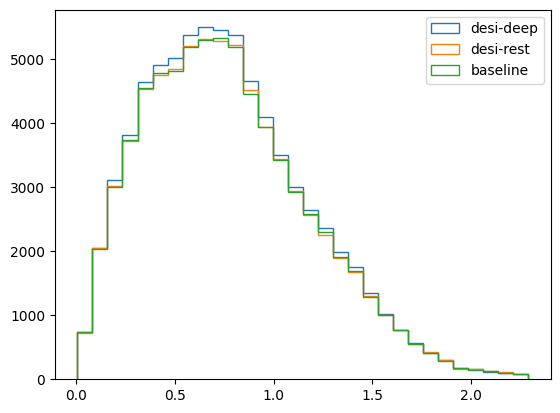

In [16]:
for sample, label in zip(samples_clean, ['desi-deep', 'desi-rest', 'baseline']):
    cc = pl.hist(sample['redshift'], bins=30, histtype='step', label=label)
pl.legend()

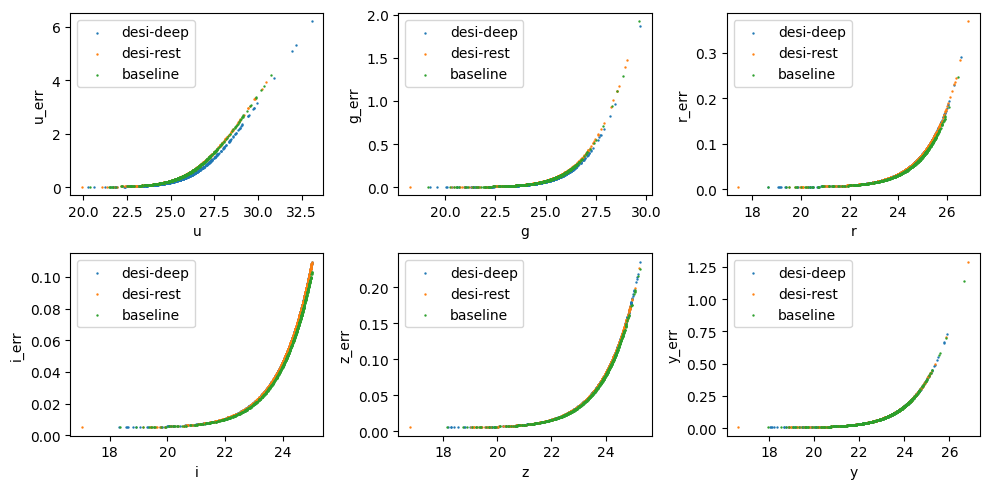

In [17]:
# show error model:
fig,axarr=pl.subplots(2,3, figsize=[10,5])
bands="ugrizy"

for i in range(2):
    for j in range(3):
        k = i*3 + j
        band = bands[k]
        pl.sca(axarr[i,j])
        for sample, label in zip(samples_clean, ['desi-deep', 'desi-rest', 'baseline']):
            pl.scatter(sample[f'mag_{band}_lsst'][::100], sample[f'mag_{band}_lsst_err'][::100], label=label, s=0.5)
        pl.legend()
        pl.xlabel(band)
        pl.ylabel(band + "_err")
pl.tight_layout()

In [32]:
# save the data files and download them:

root="/pscratch/sd/q/qhang/rubin_baseline_v5.3_desi/"

labels=["y4desi_deep", "y4desi_rest", "y4baseline"]

for sample, label in zip(samples_clean, labels):
    sample.to_parquet(root + f"cardinal_train_100k-{label}.parquet")

## test sample

In [36]:
errorModel_y4desi_deep = LSSTErrorModel.make_stage(name="error_model", m5=depth_y4desi_deep,
                                      nYrObs = 1,
                                      nVisYr ={"u":1, "g":1, "r":1, "i":1, "z":1, "y":1},
                                      extendedType="point",
                                      highSNR=False,
                                      renameDict = renameDict)
samples_y4desi_deep2 = errorModel_y4desi_deep(df2)

Inserting handle into data store.  input: None, error_model
Inserting handle into data store.  output_error_model: inprogress_output_error_model.pq, error_model


In [37]:
errorModel_y4desi_rest = LSSTErrorModel.make_stage(name="error_model", m5=depth_y4desi_rest,
                                      nYrObs = 1,
                                      nVisYr ={"u":1, "g":1, "r":1, "i":1, "z":1, "y":1},
                                      extendedType="point",
                                      highSNR=False,
                                      renameDict = renameDict)
samples_y4desi_rest2 = errorModel_y4desi_rest(df2)

Inserting handle into data store.  input: None, error_model
Inserting handle into data store.  output_error_model: inprogress_output_error_model.pq, error_model


In [38]:
errorModel_y4baseline = LSSTErrorModel.make_stage(name="error_model", m5=depth_y4baseline,
                                      nYrObs = 1,
                                      nVisYr ={"u":1, "g":1, "r":1, "i":1, "z":1, "y":1},
                                      extendedType="point",
                                      highSNR=False,
                                      renameDict = renameDict)
samples_y4baseline2 = errorModel_y4baseline(df2)

Inserting handle into data store.  input: None, error_model
Inserting handle into data store.  output_error_model: inprogress_output_error_model.pq, error_model


In [39]:
samples = [samples_y4desi_deep2(), samples_y4desi_rest2(), samples_y4baseline2()]
samples_clean2 = []
for sample in samples:
    for band in "ugrizy":
        if band == "u":
            ind = np.isfinite(sample[f'mag_{band}_lsst'])
        else:
            ind *= np.isfinite(sample[f'mag_{band}_lsst'])
        ind *= sample['mag_i_lsst'] < 25
    samples_clean2.append(sample[ind])

In [40]:
root="/pscratch/sd/q/qhang/rubin_baseline_v5.3_desi/"

labels=["y4desi_deep", "y4desi_rest", "y4baseline"]

for sample, label in zip(samples_clean2, labels):
    sample.to_parquet(root + f"cardinal_test_100k-{label}.parquet")

In [41]:
for sample, label in zip(samples_clean2, labels):
    print(len(sample))

74883
72536
72478
